In [11]:
import pandas as pd

df = pd.read_csv("../data/raw/data.csv")
df.head(10)

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0
5,TransactionId_23223,BatchId_25954,AccountId_1078,SubscriptionId_4238,CustomerId_1432,UGX,256,ProviderId_6,ProductId_3,airtime,ChannelId_3,2000.0,2000,2018-11-15T03:35:10Z,2,0
6,TransactionId_118063,BatchId_118460,AccountId_2442,SubscriptionId_1980,CustomerId_2858,UGX,256,ProviderId_5,ProductId_3,airtime,ChannelId_3,10000.0,10000,2018-11-15T03:44:31Z,4,0
7,TransactionId_100640,BatchId_38561,AccountId_4841,SubscriptionId_3829,CustomerId_2858,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-500.0,500,2018-11-15T03:45:13Z,2,0
8,TransactionId_51905,BatchId_93774,AccountId_272,SubscriptionId_4731,CustomerId_598,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,500.0,500,2018-11-15T04:14:59Z,2,0
9,TransactionId_130161,BatchId_82409,AccountId_710,SubscriptionId_920,CustomerId_1053,UGX,256,ProviderId_1,ProductId_15,financial_services,ChannelId_3,600.0,600,2018-11-15T04:31:48Z,2,0


In [3]:
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='object')

Dataset Overview Explanation
1. Number of Rows

The dataset contains:

95,662 rows

This means there are 95,662 transaction records, where each row represents a single transaction made by a customer on the eCommerce platform.

This is a moderately large dataset, which is good for:

building reliable machine learning models
capturing customer behavioral patterns
reducing risk of overfitting
2. Number of Columns

The dataset contains:

16 columns (features)

These features describe:

customer identity
transaction behavior
product information
financial values
time-based activity
and fraud label

So the dataset is tabular transactional data with mixed feature types.

3. Data Types Breakdown

The dataset contains 3 main data types:

Object (Categorical/Text Data) → 11 columns

These columns represent identifiers or categories:

TransactionId
BatchId
AccountId
SubscriptionId
CustomerId
CurrencyCode
ProviderId
ProductId
ProductCategory
ChannelId
TransactionStartTime (will be converted to datetime later)

 Meaning:
These are mostly:

customer identifiers
product identifiers
categorical transaction descriptors
time stored as string (needs conversion)

They are important for:

grouping (Customer-level aggregation)
encoding (One-Hot / Label Encoding)
feature engineering (RFM analysis)
Numerical Data → 5 columns
Float:
Amount
Integers:
CountryCode
Value
PricingStrategy
FraudResult

Meaning:
These columns represent:

transaction value
geographic encoding
pricing rules
fraud label (target for fraud detection, not main target here)

These are used for:

statistical analysis
correlation analysis
scaling (standardization/normalization)
model input features

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


Mean (Average)
Observations:
CountryCode = 256
Constant value (no variation)
Means all transactions come from the same country
Amount = 6,717
Average transaction value is positive but not very meaningful alone because of extreme outliers
Value = 9,900
Slightly higher than Amount, likely due to absolute transformation or different calculation logic
PricingStrategy = 2.25
Most transactions fall into strategy category around “2”
FraudResult = 0.002
Extremely low average → indicates strong class imbalance
Very few fraud cases exist in dataset

Standard Deviation (STD)
Observations:
Amount = 123,306
Value = 123,122

Very high standard deviation means:

data is highly spread
strong presence of extreme values (outliers)

The dataset is highly volatile financially, meaning customer transactions vary a lot.

Minimum (MIN)
Observations:
Amount = -1,000,000

Important insight:

Negative values exist → likely refunds or chargebacks
These must be handled carefully in modeling
Value = 2
Minimum transaction value is very small positive number

Maximum (MAX)
Observations:
Amount = 9,880,000
Value = 9,880,000

large max value
strong standard deviation
mean >> median
 PricingStrategy → Low Variation
Mostly constant around 2
Very low std (0.73)

Interpretation:

Limited diversity in pricing strategy
May have low predictive power alone


## Key Insights from Summary Statistics

1. Transaction Amount and Value are highly right-skewed with extreme outliers.
2. The dataset contains negative transaction amounts, likely representing refunds or reversals.
3. Fraud cases are extremely rare, indicating a highly imbalanced dataset.
4. CountryCode has no variation, meaning all transactions come from a single country.
5. High standard deviation in monetary features indicates strong variability in customer behavior.

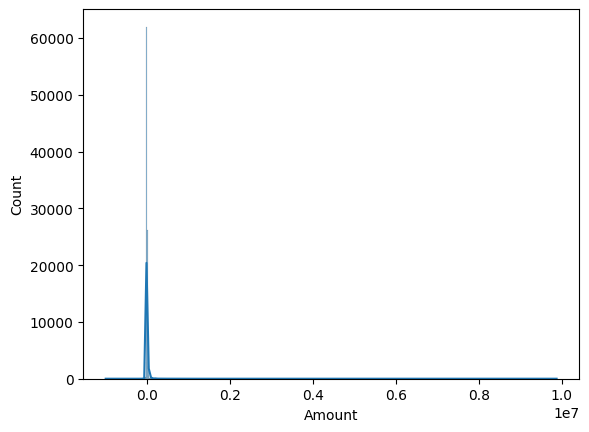

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Amount"], kde=True)
plt.show()

Skewness Observation

The distribution is highly right-skewed (positively skewed).

Evidence:
Most transaction values are concentrated near zero.
A very small number of transactions extend to extremely large values.
The long tail stretches toward the right side of the distribution.

Interpretation:

This indicates that:

most customers perform relatively small transactions,
while a few transactions have exceptionally high monetary values.

This type of distribution is very common in:

financial transactions,
banking systems,
eCommerce payment platforms.

Outlier Observation

The histogram clearly shows the presence of extreme outliers.

Evidence:
Maximum transaction values are far larger than the majority of observations.
The distribution tail extends to nearly 10 million.
Most data points are compressed into a very narrow region because of a few extreme values.

Interpretation:

These outliers may represent:

high-value purchases,
business-related transactions,
bulk payments,
or unusual financial activities.

Outliers are important because they can:

distort statistical measures such as mean and standard deviation,
negatively affect some machine learning algorithms,
and influence scaling and normalization procedures.

Concentration Observation

The distribution shows a strong concentration of observations around lower transaction amounts.

Evidence:
The highest density peak is located near zero.
Most transactions fall within a small value range.
Very few observations occupy the higher transaction regions.

 Interpretation:

This suggests that:

low-value transactions dominate the platform activity,
customer spending behavior is heavily concentrated in smaller purchases,
and customer transaction behavior is highly uneven across users.

CATEGORICAL FEATURES

In [6]:
df["ChannelId"].value_counts()

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

<Axes: xlabel='ChannelId', ylabel='count'>

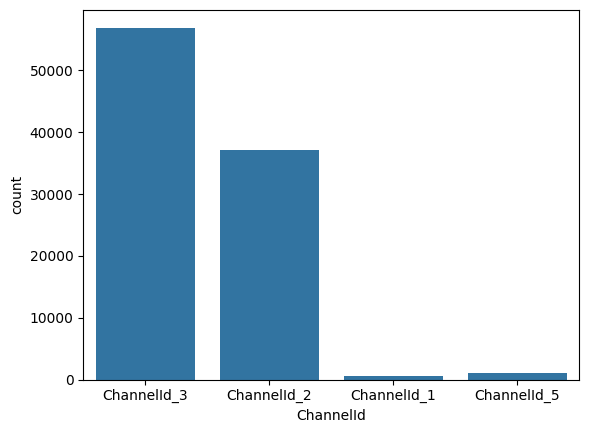

In [ ]:
sns.countplot(x="ChannelId", data=df)

Most Common Channels

The transaction activity is highly concentrated in two dominant channels:

| Channel     | Transaction Count |
| ----------- | ----------------- |
| ChannelId_3 | 56,935            |
| ChannelId_2 | 37,141            |
| ChannelId_5 | 1,048             |
| ChannelId_1 | 538               |


## Channel Distribution Analysis

The transaction distribution across channels is highly imbalanced. ChannelId_3 is the most dominant channel with more than 56,000 transactions, followed by ChannelId_2 with over 37,000 transactions. In contrast, ChannelId_1 and ChannelId_5 contribute only a very small fraction of total transactions. This indicates that customer activity is strongly concentrated around a few preferred transaction channels. Such channel preferences may provide important behavioral signals for customer segmentation and credit risk modeling.

<Axes: >

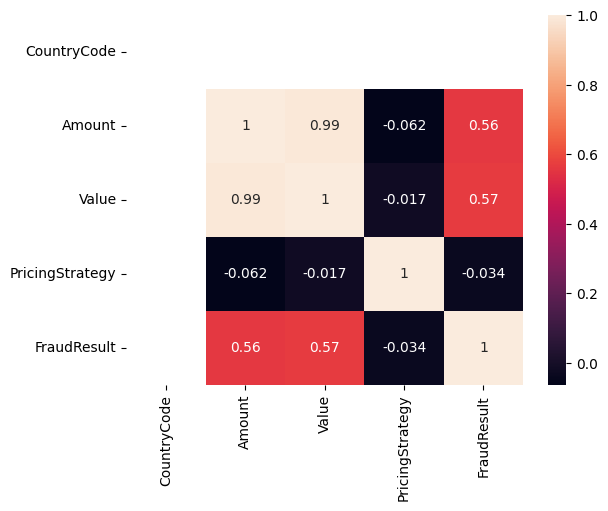

In [8]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

Correlation Analysis Interpretation

The heatmap shows the linear relationships between the numerical variables in the dataset using Pearson correlation coefficients.

Correlation values range from:

+1 → strong positive relationship
0 → no relationship
-1 → strong negative relationship
Amount vs Value → Very Strong Positive Correlation (0.99)

The correlation between Amount and Value is:

0.99

 Interpretation:

This indicates an almost perfect positive relationship between the two variables.

As transaction Amount increases, Value also increases proportionally.

This is expected because:

both variables represent transaction monetary information,
and Value appears to be closely derived from Amount.
## Correlation Analysis Insights

The correlation analysis shows a very strong positive relationship between Amount and Value (0.99), indicating that both variables capture nearly identical financial information. FraudResult has a moderate positive correlation with both Amount and Value, suggesting that larger transactions may be more associated with fraudulent activity. PricingStrategy demonstrates very weak correlations with other variables, implying limited standalone predictive power. CountryCode shows no meaningful correlation because it contains only a single constant value across all observations.

In [9]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

<Axes: xlabel='Amount'>

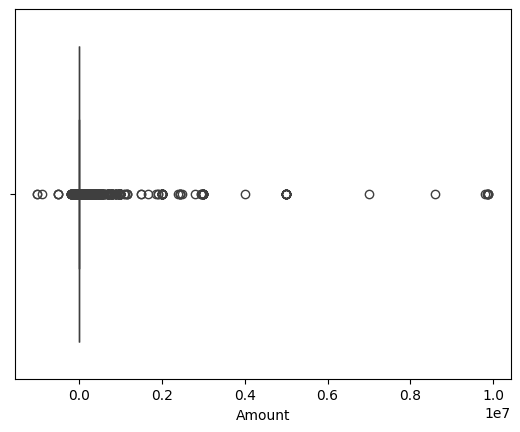

In [10]:
sns.boxplot(x=df["Amount"])

## Key Insights

1. Transaction Amount is highly right-skewed with significant outliers.
2. Most transactions occur through a few dominant channels.
3. Several categorical features have high cardinality.
4. Fraud cases are highly imbalanced.
5. Customer transaction behavior suggests strong potential for behavioral segmentation.